In [100]:
import pandas as pd
import seaborn as sns
import numpy as np
df = pd.read_csv("C:/Users/simpl/OneDrive/Documents/GitHub/tstat280/data/tacoma_houses.csv", low_memory=False)
df.head()

,Exterior Description,Directions,Fireplace Y/N,Irrigation Water Rights Y/N,Inclusions,Basement,Bedrooms Possible,Window Features,Land Lease Y/N,Garage Y/N,...,Baths Three Quarter Lower,beds,Listing Terms,View Y/N,County,Lot Features,Number of Homes in Park,Assoc/CIC,Latitude,Longitude
0,NaN,NaN,No,No,NaN,NaN,2.0,NaN,No,Yes,...,0.0,2 Beds,NaN,No,Pierce,Paved,NaN,NaN,47.253662,-122.501020
1,NaN,WA-512 (East or West) to Steele St exit. Go So...,Yes,No,"Dishwashers, Dryers, GarbageDisposal, Microwav...",NaN,3.0,NaN,No,Yes,...,0.0,3 Beds,"Cash Out, Conventional, VA Loan",Yes,Pierce,"Curbs, Dead End Street, Paved, Sidewalk",NaN,NaN,47.135711,-122.447555
2,NaN,"South on Canyon Rd, West on 176th, South on 38...",Yes,Yes,"Dishwasher(s), Dryer(s), Garbage Disposal, Lea...",NaN,4.0,NaN,No,Yes,...,0.0,4 Beds,"Cash Out, Conventional, FHA, VA Loan",NaN,Pierce,"Curbs, Dead End Street, Paved, Sidewalk",NaN,NaN,47.091209,-122.381868
3,NaN,"Head west on SW 356th, which becomes 29th St. ...",Yes,No,"Dishwasher(s), Garbage Disposal, Refrigerator(...",Finished,NaN,NaN,No,Yes,...,0.0,3 Beds,"Cash Out, Conventional, FHA, VA Loan",NaN,Pierce,"Alley, Paved, Sidewalk",NaN,NaN,47.285087,-122.369776
4,NaN,"GPS friendly. Follow Pearl to 42nd, left on 4...",No,No,"Dishwasher(s), Dryer(s), Refrigerator(s), Stov...",NaN,3.0,NaN,No,Yes,...,0.0,3 Beds,NaN,NaN,Pierce,"Curbs, Paved, Sidewalk",NaN,NaN,47.286240,-122.517141


In [59]:
import math
df["house_number"] = df["address"].str.split().str[0]
#In complete transparancy, some of the following code is produced by AI in line with your regulations on AI usage on the project.
#I can verify what is happening, even for the sections that have not been covered in class with knowledge from prior experience and documemtation and I had Claude generate the code based off of my ideas and decisions
#This first chunk is also pulled from the data cleaning portion directly. Feel free to gloss over it.
# ─────────────────────────────────────────────────────────────
# 1. INCLUSIONS
# ─────────────────────────────────────────────────────────────
# Fill missing with "None"
df['Inclusions'] = df['Inclusions'].fillna('None')

# Canonical name map — normalise plurals, spacing, and slash variants
inclusion_name_map = {
    'dishwasher(s)': 'Dishwasher', 'dishwashers': 'Dishwasher', 'dishwasher': 'Dishwasher',
    'dryer(s)': 'Dryer', 'dryers': 'Dryer', 'dryer': 'Dryer',
    'washer(s)': 'Washer', 'washers': 'Washer', 'washer': 'Washer',
    'microwave(s)': 'Microwave', 'microwaves': 'Microwave', 'microwave': 'Microwave',
    'refrigerator(s)': 'Refrigerator', 'refrigerators': 'Refrigerator', 'refrigerator': 'Refrigerator',
    "stove(s)/range(s)": 'StoveRange', 'stovesranges': 'StoveRange', 'stoverange': 'StoveRange',
    'range/oven': 'StoveRange', 'rangeoven': 'StoveRange',
    'garbage disposal': 'GarbageDisposal', 'garbagedisposal': 'GarbageDisposal', 'garbage': 'GarbageDisposal',
    'double oven': 'DoubleOven', 'doubleoven': 'DoubleOven',
    'trash compactor': 'TrashCompactor', 'trashcompactor': 'TrashCompactor',
    'leased equipment': 'LeasedEquipment', 'leasedequipment': 'LeasedEquipment',
    'security system': 'SecuritySystem', 'securitysystem': 'SecuritySystem',
    'above ground pool': 'AboveGroundPool', 'abovegroundpool': 'AboveGroundPool',
    'awnings': 'Awnings',
    'drapes': 'Drapes',
    'cable/tv': 'CableTV',
    'sewer': 'Sewer',
    'water': 'Water',
    'see remarks': None, 'seeremarks': None, 'seeremarks_': None,
    'none': None,
}

def normalise_inclusions(value):
    if pd.isna(value) or value.strip().lower() == 'none':
        return 'None'
    canonical_items = []
    for raw in value.split(','):
        key = raw.strip().lower()
        canonical = inclusion_name_map.get(key)
        if canonical:
            canonical_items.append(canonical)
    return ', '.join(sorted(set(canonical_items))) if canonical_items else 'None'

df['Inclusions'] = df['Inclusions'].apply(normalise_inclusions)


# ─────────────────────────────────────────────────────────────
# 2. TOTAL BEDROOMS  (re-derive from upper + lower)
# ─────────────────────────────────────────────────────────────
df['Bedrooms Upper'] = df['Bedrooms Upper'].fillna(0)
df['Bedrooms Lower'] = df['Bedrooms Lower'].fillna(0)
df['Total Bedrooms'] = (df['Bedrooms Upper'] + df['Bedrooms Lower']).astype(int)
df.drop(columns=['Bedrooms Upper', 'Bedrooms Lower'], inplace=True)


# ─────────────────────────────────────────────────────────────
# 3. GARAGE Y/N
# ─────────────────────────────────────────────────────────────
# Where Garage Y/N is missing, use Attached Garage value; else "No"
df['Garage Y/N'] = df['Garage Y/N'].fillna(df['Attached Garage']).fillna('No')
df['Garage Y/N'] = df['Garage Y/N'].map({'Yes': 1, 'No': 0})
df.drop(columns=['Attached Garage'], inplace=True)


# ─────────────────────────────────────────────────────────────
# 4. AIR CONDITIONING Y/N  (1 missing row → delete)
# ─────────────────────────────────────────────────────────────
df.dropna(subset=['Air Conditioning Y/N'], inplace=True)
df['Air Conditioning Y/N'] = df['Air Conditioning Y/N'].map({'Yes': 1, 'No': 0})


# ─────────────────────────────────────────────────────────────
# 5. BATHROOMS  (1 missing row → delete)
# ─────────────────────────────────────────────────────────────
df.dropna(subset=['Bathrooms'], inplace=True)
# Already floats — no further conversion needed


# ─────────────────────────────────────────────────────────────
# 6. TOTAL PARKING  (fill with median rounded down → 2)
# ─────────────────────────────────────────────────────────────
parking_median_floor = math.floor(df['Total Parking'].median())
df['Total Parking'] = df['Total Parking'].fillna(parking_median_floor).astype(int)


# ─────────────────────────────────────────────────────────────
# 7. SITE FEATURES  (missing → "None"; standardise item names)
# ─────────────────────────────────────────────────────────────
df['Site Features'] = df['Site Features'].fillna('None')

def normalise_site_features(value):
    if pd.isna(value) or value.strip().lower() == 'none':
        return 'None'
    items = sorted(set(item.strip() for item in value.split(',') if item.strip()))
    return ', '.join(items)

df['Site Features'] = df['Site Features'].apply(normalise_site_features)


# ─────────────────────────────────────────────────────────────
# 8. INTERIOR FEATURES  (missing → "None"; fix truncations, standardise names)
# ─────────────────────────────────────────────────────────────
df['Interior Features'] = df['Interior Features'].fillna('None')

# Truncated / variant entries to fix before keeping as categories
interior_fix_map = {
    # Truncations
    'fi': None, 'fir': None, 'fire': None, 'firepl': None,
    'v': None, 'vaulted c': None, 'vaulted ce': None, 'vaulted ceili': None, 'vaulted ceiling': None,
    'w': None, 'wa': None, 'wal': None, 'walk': None, 'walk-': None, 'walk-i': None, 'walk-in': None,
    'walk-in clos': None, 'walk-in close': None, 'walk-in closet(s': None,
    'walk-in pa': None, 'walk-in pant': None, 'walk-in pantr': None,
    'wall': None, 'wall to': None, 'wall to wa': None, 'wall to wall c': None,
    'wall to wall ca': None, 'wall to wall car': None, 'wall to wall carp': None,
    'wat': None, 'water h': None, 'water he': None, 'water hea': None, 'water heat': None, 'water heate': None,
    'wi': None, 'wir': None, 'wire': None, 'wired f': None, 'wired for gener': None,
    's': None, 'high t': None, 'skyligh': None, 'solarium/atr': None,
    'spr': None, 'sprinkl': None, 'sprinkler': None,
    'security sy': None, 'wine cell': None,
    # Variants
    'fir/softwood': 'Fir/Softwood',
    'walk-in closet(s)': 'Walk-In Closet(s)',
    'walk-in pantry': 'Walk-In Pantry',
    'vaulted ceiling(s)': 'Vaulted Ceiling(s)',
    'wall to wall carpet': 'Wall to Wall Carpet',
    'water heater': 'Water Heater',
    'wired for generator': 'Wired for Generator',
    'skylight(s)': 'Skylight(s)',
    'solarium/atrium': 'Solarium/Atrium',
    'sprinkler system': 'Sprinkler System',
    'security system': 'Security System',
    'wine cellar': 'Wine Cellar',
    'high tech cabling': 'High Tech Cabling',
    'fireplace (primary bedroom)': 'Fireplace (Primary Bedroom)',
}

def normalise_interior_features(value):
    if pd.isna(value) or value.strip().lower() == 'none':
        return 'None'
    clean_items = []
    for raw in value.split(','):
        item = raw.strip()
        lower = item.lower()
        mapped = interior_fix_map.get(lower, item)  # None means truncated junk → skip
        if mapped:
            clean_items.append(mapped)
    return ', '.join(sorted(set(clean_items))) if clean_items else 'None'

df['Interior Features'] = df['Interior Features'].apply(normalise_interior_features)


# ─────────────────────────────────────────────────────────────
# 9. SECURITY FEATURES  (missing → "None"; standardise names)
# ─────────────────────────────────────────────────────────────
df['Security Features'] = df['Security Features'].fillna('None')

security_name_map = {
    'fullyfenced': 'Fully Fenced',
    'partiallyfenced': 'Partially Fenced',
    'securitysystem': 'Security System',
    'securitygate': 'Security Gate',
    'securityservice': 'Security Service',
    'securityservices': 'Security Service',
    'fully fenced': 'Fully Fenced',
    'partially fenced': 'Partially Fenced',
    'security system': 'Security System',
    'security gate': 'Security Gate',
    'security service': 'Security Service',
}

def normalise_security_features(value):
    if pd.isna(value) or value.strip().lower() == 'none':
        return 'None'
    clean_items = []
    for raw in value.split(','):
        key = raw.strip().lower().replace(' ', '')
        # Try both spaced and non-spaced lookups
        canonical = security_name_map.get(raw.strip().lower()) or security_name_map.get(key)
        if canonical:
            clean_items.append(canonical)
    return ', '.join(sorted(set(clean_items))) if clean_items else 'None'

df['Security Features'] = df['Security Features'].apply(normalise_security_features)


# ─────────────────────────────────────────────────────────────
# 10. HOUSE SIZE
# ─────────────────────────────────────────────────────────────
# Remove commas and "SQFT", convert to int
df['house_size'] = (
    df['house_size']
    .str.replace(',', '', regex=False)
    .str.replace('SQFT', '', regex=False)
    .str.strip()
    .astype(int)
)


# ─────────────────────────────────────────────────────────────
# 11. TAX ANNUAL AMOUNT  (fill with mean)
# ─────────────────────────────────────────────────────────────
df['Tax Annual Amount'] = (
    df['Tax Annual Amount']
    .str.replace(r'[\$,\s]', '', regex=True)
    .replace('', np.nan)
    .astype(float)
)
tax_mean = df['Tax Annual Amount'].mean()
df['Tax Annual Amount'] = df['Tax Annual Amount'].fillna(tax_mean)


# ─────────────────────────────────────────────────────────────
# 12. YEAR BUILT → HOUSE AGE
# ─────────────────────────────────────────────────────────────
df['House Age'] = 2026 - df['Year Built']
df.drop(columns=['Year Built'], inplace=True)


# ─────────────────────────────────────────────────────────────
# 13. MLS AREA  (keep numeric code only)
# ─────────────────────────────────────────────────────────────
df['MLS Area'] = df['MLS Area'].str.extract(r'^(\d+)').astype(int)


# ─────────────────────────────────────────────────────────────
# 14. LEVELS  (pull from Stories Count where missing, else mode; standardise to float)
# ─────────────────────────────────────────────────────────────
levels_std_map = {
    'One': 1.0, 'Two': 2.0, 'Three Or More': 3.0,
    'One and One Half': 1.5, 'OneAndOneHalf': 1.5,
    'Multi/Split': 2.0,
}

# Stories Count has only the value 2.0 in this dataset
stories_to_levels = {2.0: 2.0}

def fill_levels(row):
    val = row['Levels']
    if pd.isna(val):
        sc = row['Stories Count']
        if not pd.isna(sc):
            return stories_to_levels.get(sc, np.nan)
        return np.nan
    return levels_std_map.get(val, np.nan)

df['Levels'] = df.apply(fill_levels, axis=1)

# Fill remaining NaN with mode (1.0)
levels_mode = df['Levels'].mode()[0]
df['Levels'] = df['Levels'].fillna(levels_mode)
df.drop(columns=['Stories Count'], inplace=True)


# ─────────────────────────────────────────────────────────────
# 15. LOT SIZE  (remove "Acres", convert to float)
# ─────────────────────────────────────────────────────────────
# All values are already in Acres — strip the unit and convert
df['lot_size'] = (
    df['lot_size']
    .str.replace('Acres', '', regex=False)
    .str.strip()
    .astype(float)
)


# ─────────────────────────────────────────────────────────────
# 16. FLOORING  (fill Unknown; standardise names; keep as category string)
# ─────────────────────────────────────────────────────────────
df['Flooring'] = df['Flooring'].fillna('Unknown')

flooring_name_map = {
    'Engineered Hardwood': 'Hardwood',
    'Laminate Hardwood': 'Laminate',
    'Laminate Tile': 'Laminate',
    'Bamboo/Cork': 'Bamboo',
    'See Remarks': 'Unknown',
    'Other': 'Unknown',
}

def normalise_flooring(value):
    if pd.isna(value) or value.strip().lower() == 'unknown':
        return 'Unknown'
    clean_items = []
    for raw in value.split(','):
        item = raw.strip()
        item = flooring_name_map.get(item, item)
        clean_items.append(item)
    return ', '.join(sorted(set(clean_items))) if clean_items else 'Unknown'

df['Flooring'] = df['Flooring'].apply(normalise_flooring)


# ─────────────────────────────────────────────────────────────
# 17. HOA  (fill missing with "No"; convert to binary 0/1)
# ─────────────────────────────────────────────────────────────
def hoa_to_binary(val):
    if pd.isna(val):
        return 0
    s = str(val).strip().lower()
    if s in ('no', '0', ''):
        return 0
    if s == 'yes':
        return 1
    try:
        return 0 if float(s) == 0 else 1
    except ValueError:
        return 0

df['HOA'] = df['HOA'].apply(hoa_to_binary)


# ─────────────────────────────────────────────────────────────
# 18. HOA FEE  (fill 0; remove $ and whitespace; convert to float)
# ─────────────────────────────────────────────────────────────
df['HOA Fee'] = (
    df['HOA Fee']
    .fillna('$0')
    .str.replace(r'[\$,\s]', '', regex=True)
    .replace('', '0')
    .astype(float)
)


# ─────────────────────────────────────────────────────────────
# 19. PROPERTY CONDITION  (fill Unknown; standardise; map to ordinal)
# ─────────────────────────────────────────────────────────────
df['Property Condition'] = df['Property Condition'].fillna('Unknown')

property_condition_map = {
    'Fixer': 1,
    'Fair': 2,
    'Average': 3,
    'Resale': 3,
    'Good': 4,
    'Restored': 4,
    'Very Good': 5,
    'Remodeled': 5,
    'Updated/Remodeled': 5,
    'Under Construction': 5,
    'Unknown': 0,
}

df['Property Condition'] = df['Property Condition'].map(property_condition_map).fillna(0).astype(int)


# ─────────────────────────────────────────────────────────────
# 20. FOUNDATION DETAILS  (fill Unknown; standardise names; keep as category string)
# ─────────────────────────────────────────────────────────────
df['Foundation Details'] = df['Foundation Details'].fillna('Unknown')

foundation_name_map = {
    'Concrete Slab': 'Slab',
    'See Remarks': 'Unknown',
}

def normalise_foundation(value):
    if pd.isna(value) or value.strip().lower() == 'unknown':
        return 'Unknown'
    clean_items = []
    for raw in value.split(','):
        item = raw.strip()
        item = foundation_name_map.get(item, item)
        clean_items.append(item)
    return ', '.join(sorted(set(clean_items))) if clean_items else 'Unknown'

df['Foundation Details'] = df['Foundation Details'].apply(normalise_foundation)


# ─────────────────────────────────────────────────────────────
# 21. LOT FEATURES  (fill None; standardise names; keep as category string)
# ─────────────────────────────────────────────────────────────
df['Lot Features'] = df['Lot Features'].fillna('None')

lot_feature_name_map = {
    'Drought Res Landscape': 'Drought Resistant Landscape',
}

def normalise_lot_features(value):
    if pd.isna(value) or value.strip().lower() == 'none':
        return 'None'
    clean_items = []
    for raw in value.split(','):
        item = raw.strip()
        item = lot_feature_name_map.get(item, item)
        clean_items.append(item)
    return ', '.join(sorted(set(clean_items))) if clean_items else 'None'

df['Lot Features'] = df['Lot Features'].apply(normalise_lot_features)


# ─────────────────────────────────────────────────────────────
# FINAL: Keep only cleaned target columns
# ─────────────────────────────────────────────────────────────
final_cols = [
    'Total Bedrooms', 'Garage Y/N', 'Air Conditioning Y/N', 'Bathrooms',
    'Total Parking', 'Inclusions', 'Site Features', 'Interior Features',
    'Security Features', 'house_size', 'Tax Annual Amount', 'House Age',
    'MLS Area', 'Levels', 'lot_size', 'Flooring', 'HOA', 'HOA Fee',
    'Property Condition', 'Foundation Details', 'Lot Features',
]

df["Close Price"] = (
    df["Close Price"].str.replace("$", "")
    .str.replace(",", "")
    .astype("int")
)
df["price"] = (
    df["price"].str.replace("$", "")
    .str.replace(",", "")
    .astype("int")
)


df["log_price"] = np.log(df["price"] +1)

df["log_Close Price"] = np.log(df["Close Price"] +1)


In [60]:
df.head()

,Exterior Description,Directions,Fireplace Y/N,Irrigation Water Rights Y/N,Inclusions,Basement,Bedrooms Possible,Window Features,Land Lease Y/N,Garage Y/N,...,County,Lot Features,Number of Homes in Park,Assoc/CIC,Latitude,Longitude,house_number,House Age,log_price,log_Close Price
0,NaN,NaN,No,No,None,NaN,2.0,NaN,No,1,...,Pierce,Paved,NaN,NaN,47.253662,-122.501020,722,76,12.542548,12.542548
1,NaN,WA-512 (East or West) to Steele St exit. Go So...,Yes,No,"Dishwasher, Dryer, GarbageDisposal, Microwave,...",NaN,3.0,NaN,No,1,...,Pierce,"Curbs, Dead End Street, Paved, Sidewalk",NaN,NaN,47.135711,-122.447555,13322,8,13.180634,13.180634
2,NaN,"South on Canyon Rd, West on 176th, South on 38...",Yes,Yes,"Dishwasher, Dryer, GarbageDisposal, LeasedEqui...",NaN,4.0,NaN,No,1,...,Pierce,"Curbs, Dead End Street, Paved, Sidewalk",NaN,NaN,47.091209,-122.381868,18201,1,13.280991,13.280991
3,NaN,"Head west on SW 356th, which becomes 29th St. ...",Yes,No,"Dishwasher, GarbageDisposal, Refrigerator, Sto...",Finished,NaN,NaN,No,1,...,Pierce,"Alley, Paved, Sidewalk",NaN,NaN,47.285087,-122.369776,3111,37,13.180634,13.180634
4,NaN,"GPS friendly. Follow Pearl to 42nd, left on 4...",No,No,"Dishwasher, Dryer, Refrigerator, StoveRange, W...",NaN,3.0,NaN,No,1,...,Pierce,"Curbs, Paved, Sidewalk",NaN,NaN,47.286240,-122.517141,6010,44,13.071072,13.071072


(Part 1)
Create a visualization of the response variable. Determine if any transformation should be applied to the response to make the data look more "normal".

<Axes: xlabel='price', ylabel='Count'>

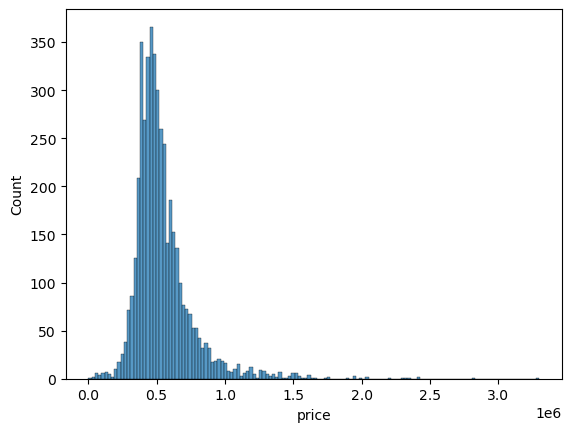

In [61]:
sns.histplot(df["price"])

<Axes: xlabel='log_price', ylabel='Count'>

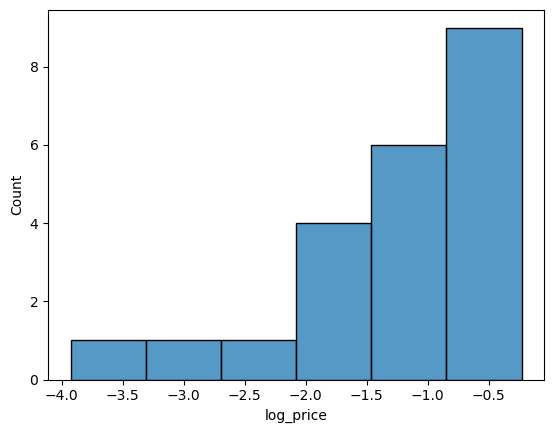

In [79]:
df["log_price"] = np.log(df["price"])

sns.histplot(df["log_price"])

<Axes: xlabel='house_size', ylabel='Count'>

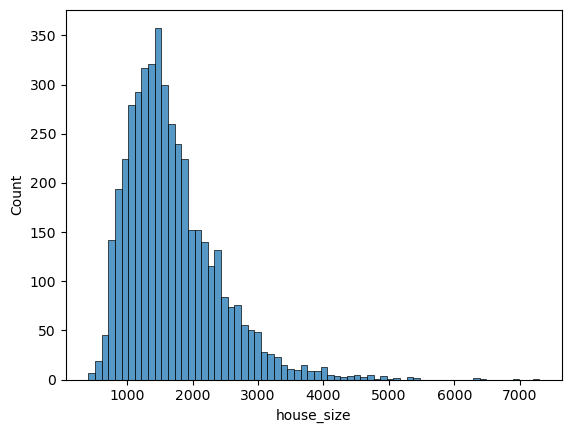

In [63]:
sns.histplot(df["house_size"])

<Axes: xlabel='Total Bedrooms', ylabel='count'>

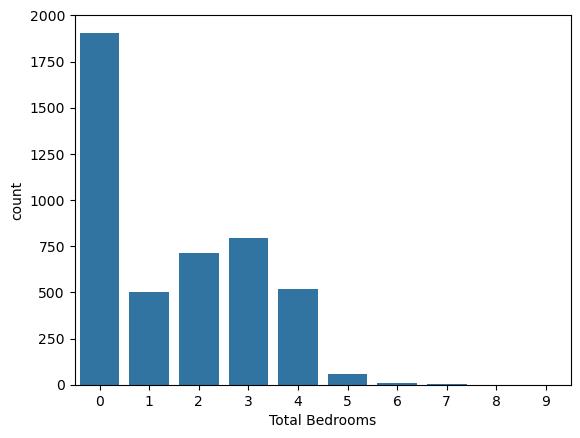

In [64]:
sns.countplot(data=df, x="Total Bedrooms")

<Axes: xlabel='Bathrooms', ylabel='Count'>

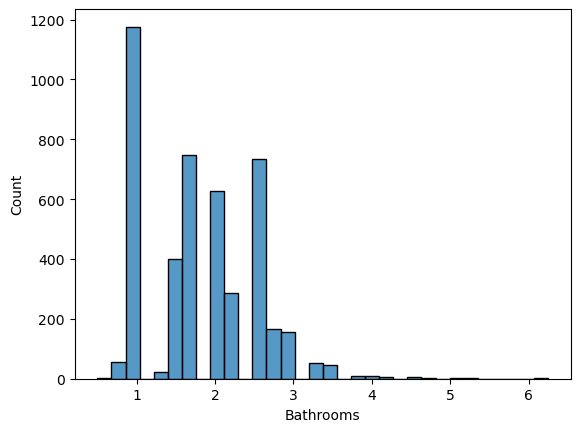

In [65]:
sns.histplot(df["Bathrooms"])

<Axes: xlabel='lot_size', ylabel='Count'>

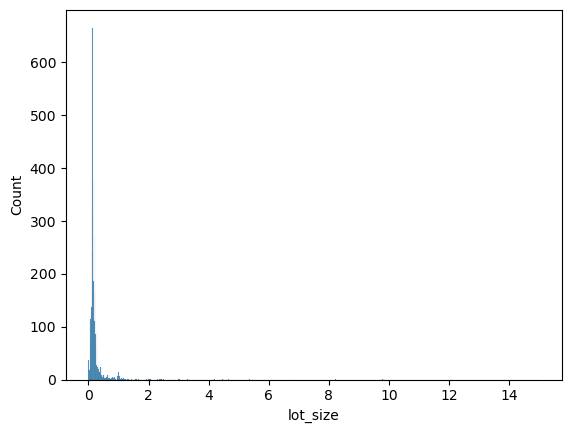

In [66]:
sns.histplot(df["lot_size"])

(Part 2)

<Axes: >

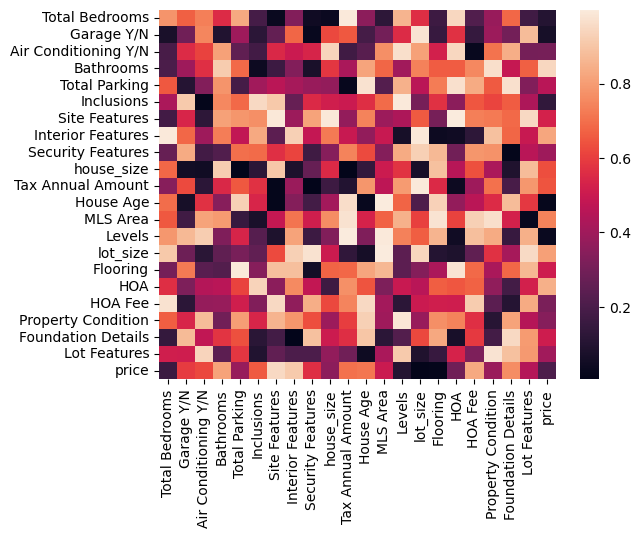

In [82]:
final_cols = [
    'Total Bedrooms', 'Garage Y/N', 'Air Conditioning Y/N', 'Bathrooms',
    'Total Parking', 'Inclusions', 'Site Features', 'Interior Features',
    'Security Features', 'house_size', 'Tax Annual Amount', 'House Age',
    'MLS Area', 'Levels', 'lot_size', 'Flooring', 'HOA', 'HOA Fee',
    'Property Condition', 'Foundation Details', 'Lot Features', 'price'
]
df = pd.DataFrame(data, columns=final_cols, index=final_cols)
sns.heatmap(df)

1) HOA can be condensed down to solely the HOA fee column.

2) The variable with the highest correlation are house size, bathrooms, and bedrooms.

4. These same variables listed above could indicate the amount of people a house could hold.

<Axes: xlabel='Bathrooms', ylabel='price'>

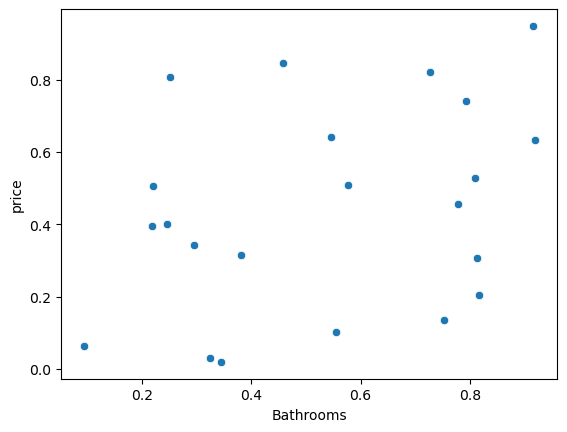

In [89]:
sns.scatterplot(
    data=df,
    x="Bathrooms",
    y="price"
)

<Axes: xlabel='house_size', ylabel='price'>

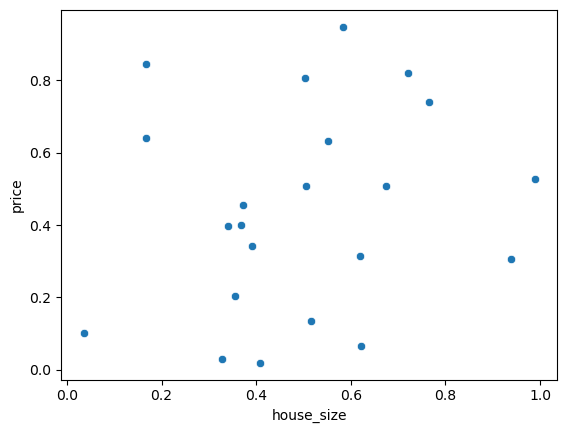

In [92]:
sns.scatterplot(
    data=df,
    x="house_size",
    y="price"
)

<Axes: xlabel='lot_size', ylabel='price'>

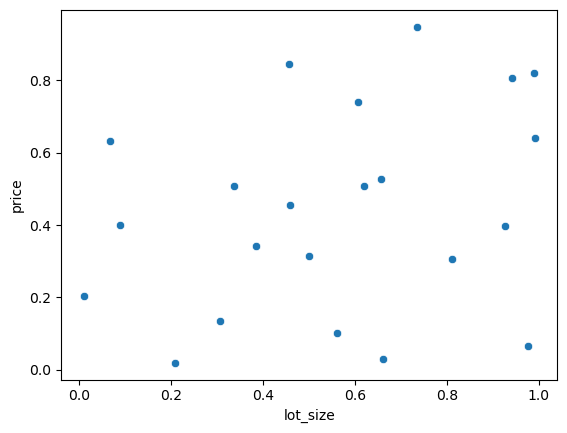

In [93]:
sns.scatterplot(
    data=df,
    x="lot_size",
    y="price"
)

<Axes: xlabel='Total Bedrooms', ylabel='price'>

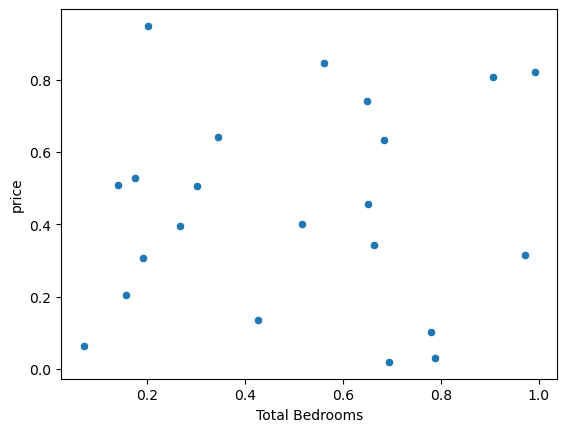

In [94]:
sns.scatterplot(
    data=df,
    x="Total Bedrooms",
    y="price"
)

3) We should change lot-size with a log transformation.

(Part 3)
Age of house could be a good feature to look at.

<Axes: xlabel='House Age', ylabel='price'>

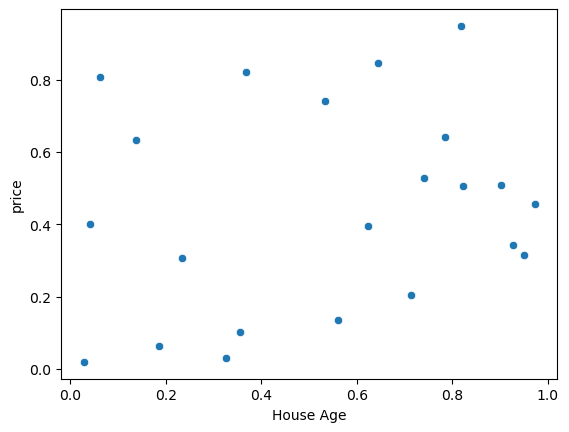

In [97]:
sns.scatterplot(
    data=df,
    x="House Age",
    y="price"
)

There surprisingly doesn't show much of a linear correlation.